# Testing SNEC dev
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser
import astropy.units as u
from plot_v_r import plot_vel_radius_at_time_t

In [2]:
root = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/"
baseline = root+"baseline/"
testing = root+"testing/"

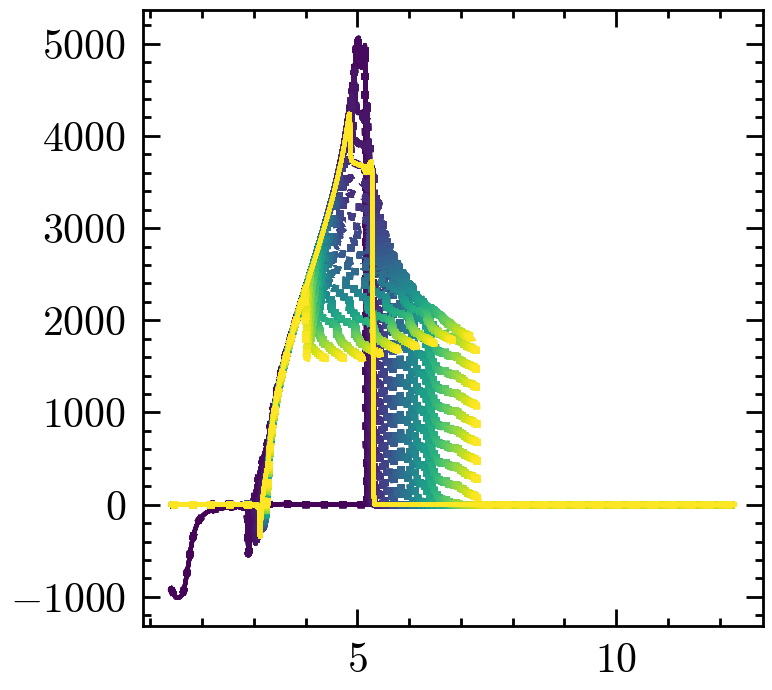

In [9]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_vel = baseline+"vel.xg"
testing_vel = testing+"vel.xg"

times = np.linspace(0, 86400, 100)
colors = plt.cm.viridis(np.linspace(0,1, len(times)))
for i, t in enumerate(times):
    plot_vel_radius_at_time_t(t, baseline_vel, ax=ax, ls='-', c=colors[i])
    plot_vel_radius_at_time_t(t, testing_vel, ax=ax, ls=':', lw=5, c=colors[i])


In [25]:
def plot_mass_radius(t, mass_out, ax=None, **kwargs):
    data = SNEC_output_parser(mass_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = t.unit
    except AttributeError:
        t *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    mass = data[key_of_interest][:, 1] * u.g
    radius = data[key_of_interest][:, 0] * u.cm
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(150, 100)
        ax = fig.add_subplot(gs[:, :])
    ax.plot(radius.to(u.cm), mass.to(u.Msun), **kwargs)
    return mass, radius

[0.267004 0.004874 0.329415 1.      ] [0.993248 0.906157 0.143936 1.      ]


Text(0, 0.5, '$m \\ [M_{\\odot}]$')

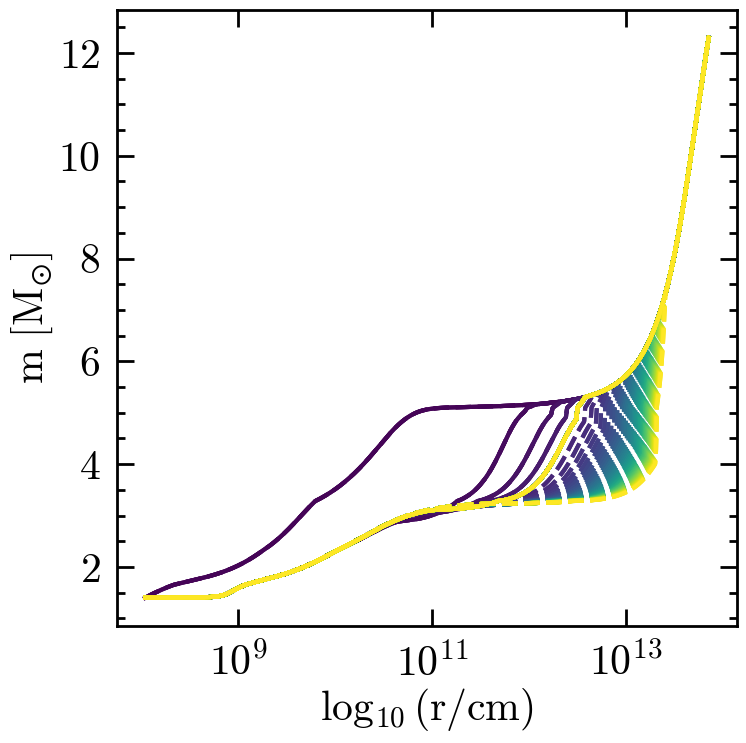

In [29]:
# mass vs time
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_mass = baseline+"mass.xg"
testing_mass = testing+"mass.xg"

times = np.linspace(0, 86400, 100)
colors = plt.cm.viridis(np.linspace(0,1, len(times)))
print(colors[0], colors[-1])
for i, t in enumerate(times):
    plot_mass_radius(t, baseline_mass, ls='-', c=colors[i], ax=ax)
    plot_mass_radius(t, testing_mass, ls='--', c=colors[i], ax=ax)

ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")
ax.set_ylabel(r"$m \ [M_{\odot}]$")